## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error


## Pretreatement before adding 'quality_score' feature

In [4]:
data = pd.read_csv('/content/cleanwelddata_filled_ssl.csv')
data.drop("Unnamed: 0.1", axis = 1, inplace=True)
data.drop("Unnamed: 0", axis = 1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Carbon concentration (weight%)             1639 non-null   float64
 1   Silicon concentration (weight%)            1639 non-null   float64
 2   Manganese concentration (weight%)          1639 non-null   float64
 3   Sulphur concentration (weight%)            1639 non-null   float64
 4   Phosphorus concentration (weight%)         1639 non-null   float64
 5   Nickel concentration (weight%)             1639 non-null   float64
 6   Chromium concentration (weight%)           1639 non-null   float64
 7   Molybdenum concentration (weight%)         1639 non-null   float64
 8   Vanadium concentration (weight%)           1639 non-null   float64
 9   Copper concentration (weight%)             1639 non-null   float64
 10  Cobalt concentration (we

### We can remove Charpy temperature and Charpy impact toughness since they are experimental parameters that are already fixed.

In [5]:
data = data.drop("Charpy temperature (°C)", axis = 1)
data = data.drop("Charpy impact toughness (J)", axis = 1)

## Creating 'quality_score' feature

In [6]:
score_variables=['Ultimate tensile strength (MPa)',
'Elongation (%)',
'Reduction of Area (%)']

score_features_df = data[score_variables]
score_features_df["quality_score"]=np.sqrt((score_features_df[score_variables]**2).mean(axis=1))
data['quality_score'] = score_features_df['quality_score']

/tmp/ipython-input-4074704271.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  score_features_df["quality_score"]=np.sqrt((score_features_df[score_variables]**2).mean(axis=1))


## Supervised Models for predicting 'quality_score'

In [7]:
data_clean = data.dropna(subset=['quality_score'])
data_X = data_clean.drop(columns=['Ultimate tensile strength (MPa)', 'Yield strength (MPa)', 'Elongation (%)',
                                  'Reduction of Area (%)', 'quality_score'], axis = 1)

X = data_X
y = data_clean.loc[X.index, 'quality_score']

### Stratified Split

In [8]:
n_bins = 10
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
y_binned = discretizer.fit_transform(y.values.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y_binned, random_state=42)

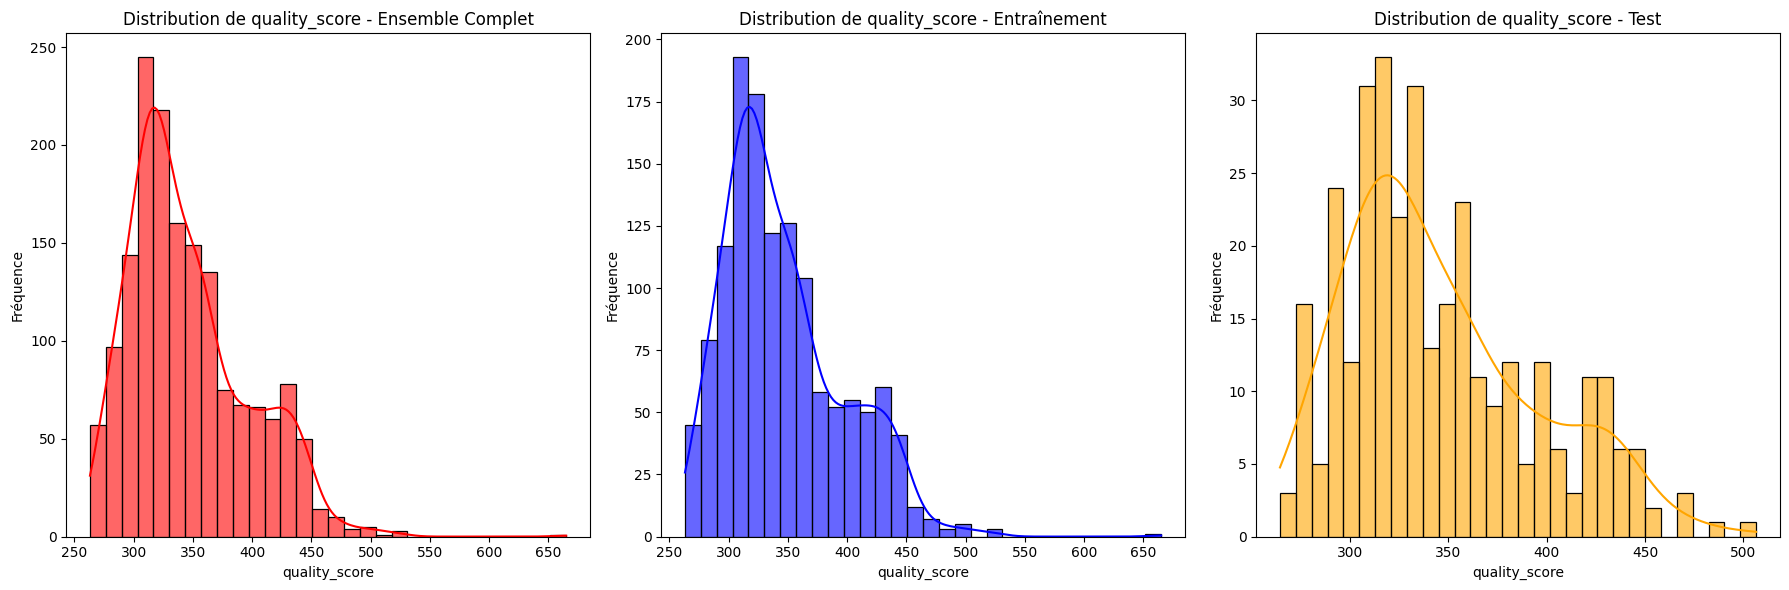

In [9]:
plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
sns.histplot(y, bins=30, kde=True, color='red', alpha=0.6)
plt.title('Distribution de quality_score - Ensemble Complet')
plt.xlabel('quality_score')
plt.ylabel('Fréquence')

plt.subplot(1, 3, 2)
sns.histplot(y_train, bins=30, kde=True, color='blue', alpha=0.6)
plt.title('Distribution de quality_score - Entraînement')
plt.xlabel('quality_score')
plt.ylabel('Fréquence')

#
plt.subplot(1, 3, 3)
sns.histplot(y_test, bins=30, kde=True, color='orange', alpha=0.6)
plt.title('Distribution de quality_score - Test')
plt.xlabel('quality_score')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

# **1. Random Forest**

#### We use Grid Search to find the best hyperparameters

In [10]:
param_grid = {
    'n_estimators': [200, 400,600],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}


In [11]:
rf_regressor = RandomForestRegressor(**grid_search.best_params_)
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=5, n_estimators=400)

In [15]:
y_train_pred = rf_regressor.predict(X_train)
y_test_pred = rf_regressor.predict(X_test)

Text(0, 0.5, 'Valeurs prédites (Test)')

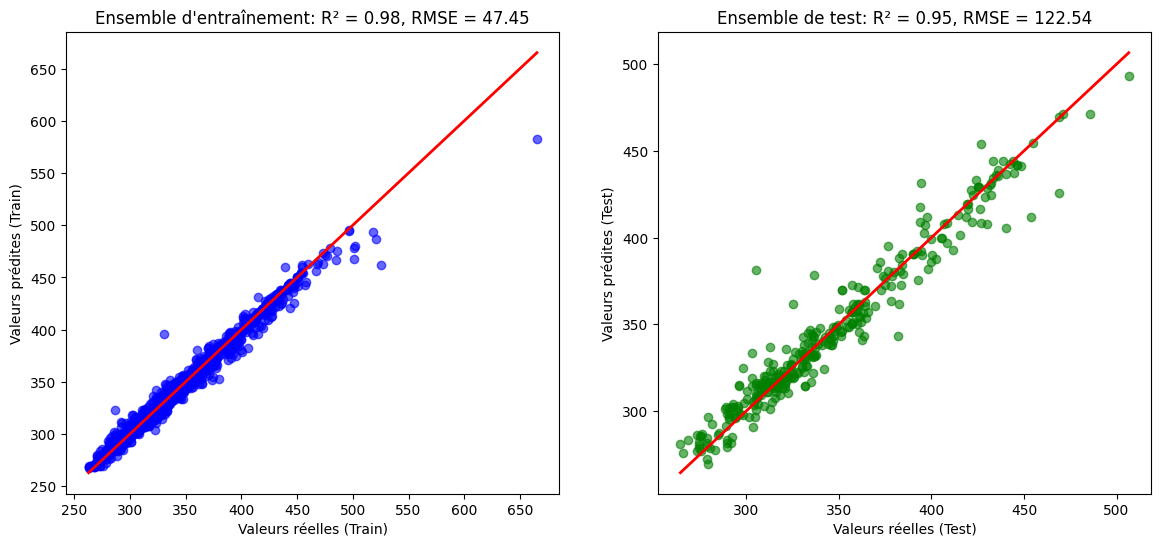

In [17]:
r2_train = r2_score(y_train, y_train_pred)
rmse_train = mean_squared_error(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', lw=2)
plt.title(f'Ensemble d\'entraînement: R² = {r2_train:.2f}, RMSE = {rmse_train:.2f}')
plt.xlabel('Valeurs réelles (Train)')
plt.ylabel('Valeurs prédites (Train)')


plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title(f'Ensemble de test: R² = {r2_test:.2f}, RMSE = {rmse_test:.2f}')
plt.xlabel('Valeurs réelles (Test)')
plt.ylabel('Valeurs prédites (Test)')

### Feature Importance

                                      Feature  Importance
6            Chromium concentration (weight%)    0.278929
7          Molybdenum concentration (weight%)    0.218401
2           Manganese concentration (weight%)    0.132050
8            Vanadium concentration (weight%)    0.088688
5              Nickel concentration (weight%)    0.075480
17      Niobium concentration (ppm by weight)    0.034123
1             Silicon concentration (weight%)    0.033091
28      Post weld heat treatment time (hours)    0.030667
9              Copper concentration (weight%)    0.013707
12       Oxygen concentration (ppm by weight)    0.011496
0              Carbon concentration (weight%)    0.011451
22                                Voltage (V)    0.011075
14     Nitrogen concentration (ppm by weight)    0.010375
21                                Current (A)    0.008653
27  Post weld heat treatment temperature (°C)    0.007921
13     Titanium concentration (ppm by weight)    0.005525
15    Aluminiu

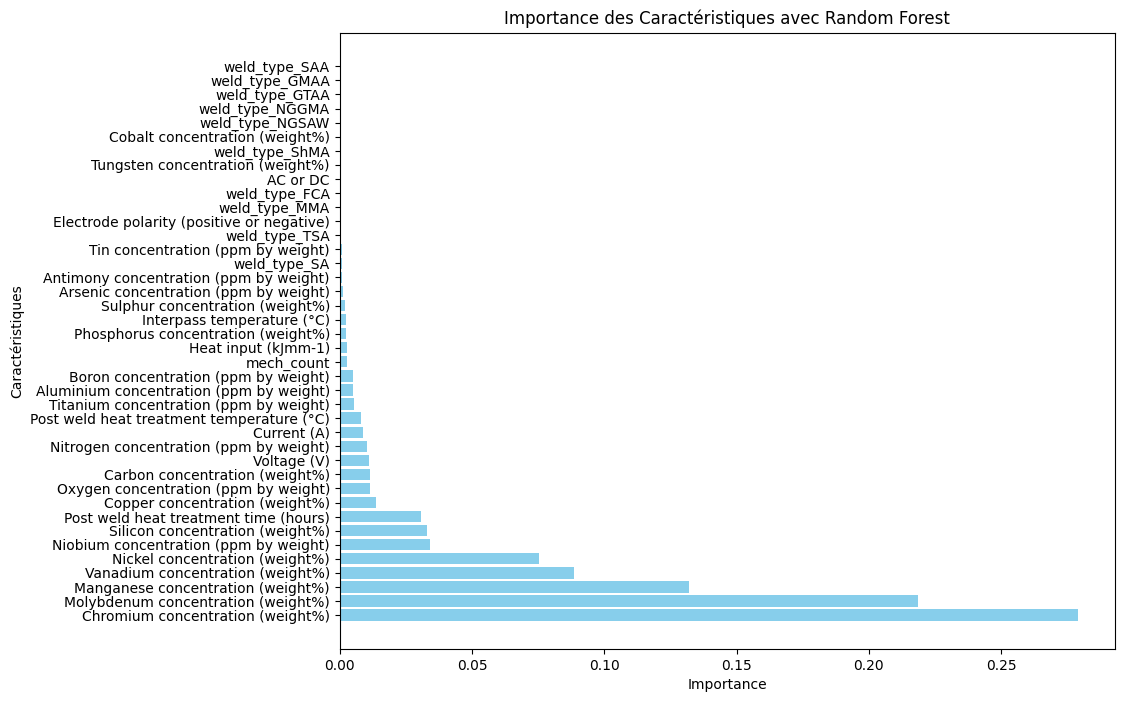

In [18]:
importances = rf_regressor.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)


plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('Importance des Caractéristiques avec Random Forest')
plt.xlabel('Importance')
plt.ylabel('Caractéristiques')
plt.show()

# **2.XGBOOST**

In [25]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    'n_estimators': [150,200],
    'max_depth': [3,5],
    'learning_rate': [ 0.05],
    'subsample': [ 0.7],
    'colsample_bytree': [0.7, 0.9, 0.5],
    'reg_lambda': [5],
    'min_child_weight': [1]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print(f"Best Hyperparameters: {best_params}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Hyperparameters: {'subsample': 0.7, 'reg_lambda': 5, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [26]:
xgb_model_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params
)

xgb_model_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
y_train_pred = xgb_model_tuned.predict(X_train)
y_test_pred = xgb_model_tuned.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = mean_squared_error(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred)

Text(0, 0.5, 'Valeurs prédites (Test)')

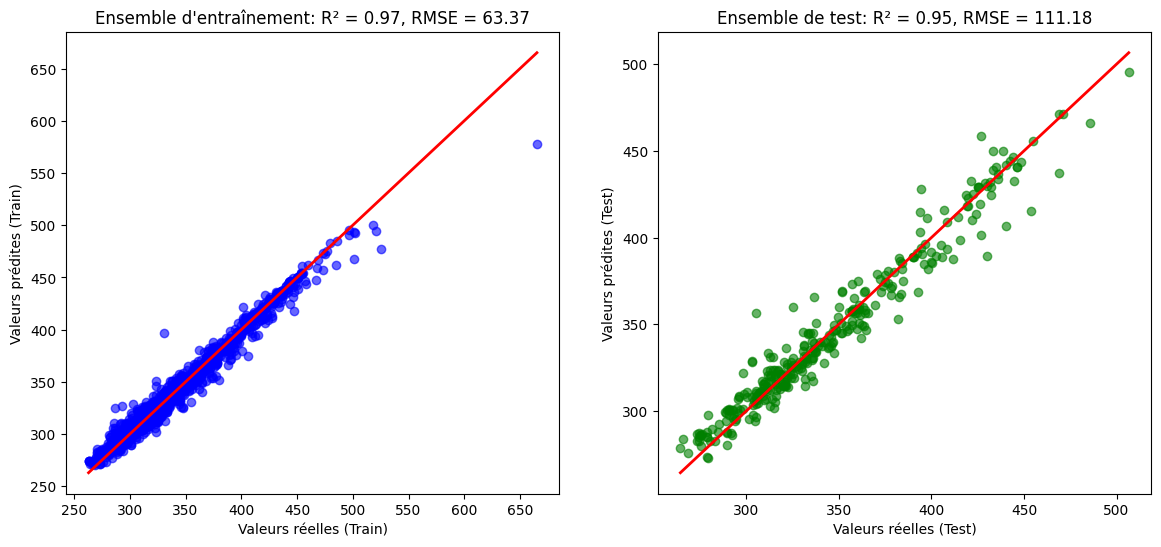

In [28]:
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', lw=2)
plt.title(f'Ensemble d\'entraînement: R² = {r2_train:.2f}, RMSE = {rmse_train:.2f}')
plt.xlabel('Valeurs réelles (Train)')
plt.ylabel('Valeurs prédites (Train)')


plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title(f'Ensemble de test: R² = {r2_test:.2f}, RMSE = {rmse_test:.2f}')
plt.xlabel('Valeurs réelles (Test)')
plt.ylabel('Valeurs prédites (Test)')

### Feature Importance

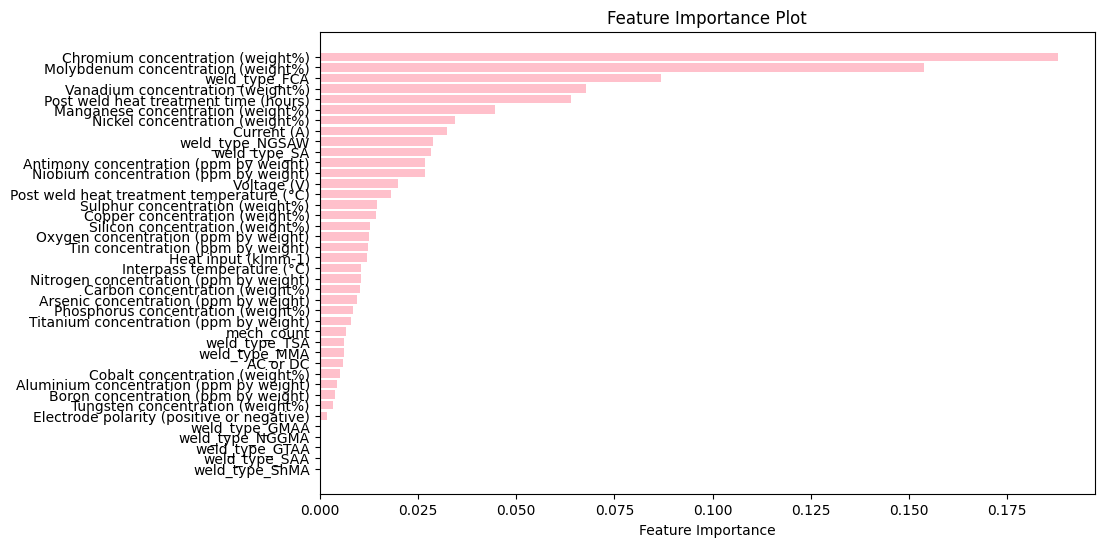

In [29]:
importance = xgb_model_tuned.feature_importances_

features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='pink')
plt.xlabel('Feature Importance')
plt.title('Feature Importance Plot')
plt.gca().invert_yaxis()
plt.show()